In [3]:
import sys
from pathlib import Path

scripts_dir = Path.cwd().parent / "scripts"
sys.path.insert(0, str(scripts_dir))

In [4]:
# Path to test .mrxs
path_CMU1 = r"E:\Christine\testdata\CMU-1.mrxs"
path_CMU3 = r"E:\Christine\testdata\CMU-3.mrxs"
zarr_dir = r"E:\Christine\testdata\zarr"
cache_tissue = r"E:\Christine\testdata\cache_tissue_artifact.pkl"
cache_features = r"E:\Christine\testdata\feature_summary.csv"

slides = [path_CMU1, path_CMU3]

In [3]:
from tissue_artifact_segmentation import SegmentMany

segmenter = SegmentMany(slides, cache_tissue, zarr_dir, "tissue", version="default")

C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
tissue segmentation:   0%|          | 0/2 [00:00<?, ?it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: i

Tissue already segmented: tissue_default
Tissue processing complete for E:\Christine\testdata\zarr\CMU-1.zarr


C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
tissue segmentation: 100%|██████████| 2/2 [00:00<00:00,  2.79it/s]

Tissue already segmented: tissue_default
Tissue processing complete for E:\Christine\testdata\zarr\CMU-3.zarr


C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_va

WSI: E:\Christine\testdata\CMU-3.mrxs
Reader: openslide
Dimensions: 220696×109240 (h×w), 10 Pyramids
Pixel physical size: 0.2325 MPP
SpatialData object, with associated Zarr store: E:\Christine\testdata\zarr\CMU-3.zarr
├── Images
│     └── 'wsi_thumbnail': DataArray[cyx] (3, 989, 489)
├── Shapes
│     ├── 'tiles_224': GeoDataFrame shape: (34417, 3) (2D shapes)
│     ├── 'tiles_px512_mpp1.5_overlap0.1': GeoDataFrame shape: (175, 3) (2D shapes)
│     └── 'tissue_default': GeoDataFrame shape: (5, 2) (2D shapes)
└── Tables
      └── 'features_h-optimus-0': AnnData (34417, 1536)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images), tiles_224 (Shapes), tiles_px512_mpp1.5_overlap0.1 (Shapes), tissue_default (Shapes)
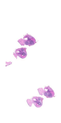

In [5]:
# Visualize Single Slide
import os
from wsidata import open_wsi

zarr_path = os.path.join(zarr_dir, os.path.basename(path_CMU3).replace(".mrxs", ".zarr"))
wsi = open_wsi(path_CMU3, zarr_path)
wsi

In [5]:
from feature_extraction import ExtractMany

model = "h-optimus-0"
extractor = ExtractMany(slides, cache_features, zarr_dir, model, remove_artifacts = False)

Found 2 slides already processed.
0 remaining to process.


feature extraction progress:   0%|          | 0/2 [00:00<?, ?it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04



Processing CMU-1.mrxs...


C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Processing complete for E:\Christine\testdata\zarr\CMU-1.zarr
Appended result for CMU-1.mrxs → E:\Christine\testdata\feature_summary.csv


feature extraction progress:  50%|█████     | 1/2 [00:01<00:01,  1.88s/it]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)



Processing CMU-3.mrxs...
Processing complete for E:\Christine\testdata\zarr\CMU-3.zarr
Appended result for CMU-3.mrxs → E:\Christine\testdata\feature_summary.csv


feature extraction progress: 100%|██████████| 2/2 [00:03<00:00,  1.98s/it]


In [6]:
# Generate df that resembles pathology df in 100k project
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "filename": [str(x) for x in slides],
    "class":  np.random.randint(0, 2, size=len(slides))
}).reset_index(drop=True)

times = 10
df_expanded = pd.DataFrame(np.repeat(df.values, times, axis=0), columns=df.columns)

print(df_expanded)

                            filename class
0   E:\Christine\testdata\CMU-1.mrxs     1
1   E:\Christine\testdata\CMU-1.mrxs     1
2   E:\Christine\testdata\CMU-1.mrxs     1
3   E:\Christine\testdata\CMU-1.mrxs     1
4   E:\Christine\testdata\CMU-1.mrxs     1
5   E:\Christine\testdata\CMU-1.mrxs     1
6   E:\Christine\testdata\CMU-1.mrxs     1
7   E:\Christine\testdata\CMU-1.mrxs     1
8   E:\Christine\testdata\CMU-1.mrxs     1
9   E:\Christine\testdata\CMU-1.mrxs     1
10  E:\Christine\testdata\CMU-3.mrxs     1
11  E:\Christine\testdata\CMU-3.mrxs     1
12  E:\Christine\testdata\CMU-3.mrxs     1
13  E:\Christine\testdata\CMU-3.mrxs     1
14  E:\Christine\testdata\CMU-3.mrxs     1
15  E:\Christine\testdata\CMU-3.mrxs     1
16  E:\Christine\testdata\CMU-3.mrxs     1
17  E:\Christine\testdata\CMU-3.mrxs     1
18  E:\Christine\testdata\CMU-3.mrxs     1
19  E:\Christine\testdata\CMU-3.mrxs     1


In [7]:
from abmil import TrainABMILPipeline

abmil_path = r"E:\Christine\testdata\abmil.pt"

pipeline = TrainABMILPipeline(df_expanded, 'filename', 'class', 'features_h-optimus-0', 'tiles_224', zarr_dir, abmil_path)
pipeline.run_pipeline(max_tiles=50000, n_epochs=10, seed=42, validation_fraction=0.10, early_stopping_patience=5)

TrainABMILPipeline initialized with 20 slides on device: cuda

Validating 20 slides...


Validating slides:   0%|          | 0/20 [00:00<?, ?it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
Validating slides:   5%|▌         | 1/20 [00:00<00:18,  1.03it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
Validating slides:  10%|█         | 2/20 [00:01<00:10,  1.73it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor,

Dataset validation complete: 20/20 valid slides
Validation complete: 20 valid slides (removed 0)


Epoch 1/10:   0%|          | 0/18 [00:00<?, ?it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)

Epoch 1/10:   6%|▌         | 1/18 [00:00<00:09,  1.73it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)

Epoch 1/10:  11%|█         | 2/18 [00:01<00:10,  1.56it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs

Epoch 1/10 | Loss: 0.2250

...


Epoch 9/10:   0%|          | 0/20 [00:00<?, ?it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)

Epoch 9/10:   5%|▌         | 1/20 [00:00<00:08,  2.32it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)

Epoch 9/10:  10%|█         | 2/20 [00:00<00:07,  2.30it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwarg

Epoch 9/10 | Loss: 0.2500



Epoch 10/10:   0%|          | 0/20 [00:00<?, ?it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)

Epoch 10/10:   5%|▌         | 1/20 [00:00<00:10,  1.73it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)

Epoch 10/10:  10%|█         | 2/20 [00:01<00:09,  1.81it/s]version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kw

Epoch 10/10 | Loss: 0.2500
Saved checkpoint to E:\Christine\testdata\abmil.pt


(ABMIL(
   (attn_V): Sequential(
     (0): Linear(in_features=1536, out_features=256, bias=True)
     (1): Tanh()
   )
   (attn_U): Sequential(
     (0): Linear(in_features=1536, out_features=256, bias=True)
     (1): Sigmoid()
   )
   (attn_w): Linear(in_features=256, out_features=4, bias=True)
   (classifier): Linear(in_features=1536, out_features=1, bias=True)
 ),
 {1: 0},
 'E:\\Christine\\testdata\\abmil.pt')

In [11]:
from abmil import ABMILInference

abmil_path = r"E:\Christine\testdata\abmil.pt"
inference_path = r"E:\Christine\testdata\inference.pkl"

inference = ABMILInference(checkpoint_path=abmil_path, zarr_dir=zarr_dir, slides=slides, cache_path=inference_path)
inference.process_slides(validate = True)

version mismatch: detected: RasterFormatV02, requested: FormatV04


Loaded checkpoint from E:\Christine\testdata\abmil.pt
Model config: in_dim=1536, n_classes=1, hidden_dim=256, n_heads = 4
Label mapping: {1: 0}


C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04


Validation complete: 2/2 valid slides; 0 skipped.


C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _

Processed 2/2 slides.
Cache saved to E:\Christine\testdata\inference.pkl.


version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


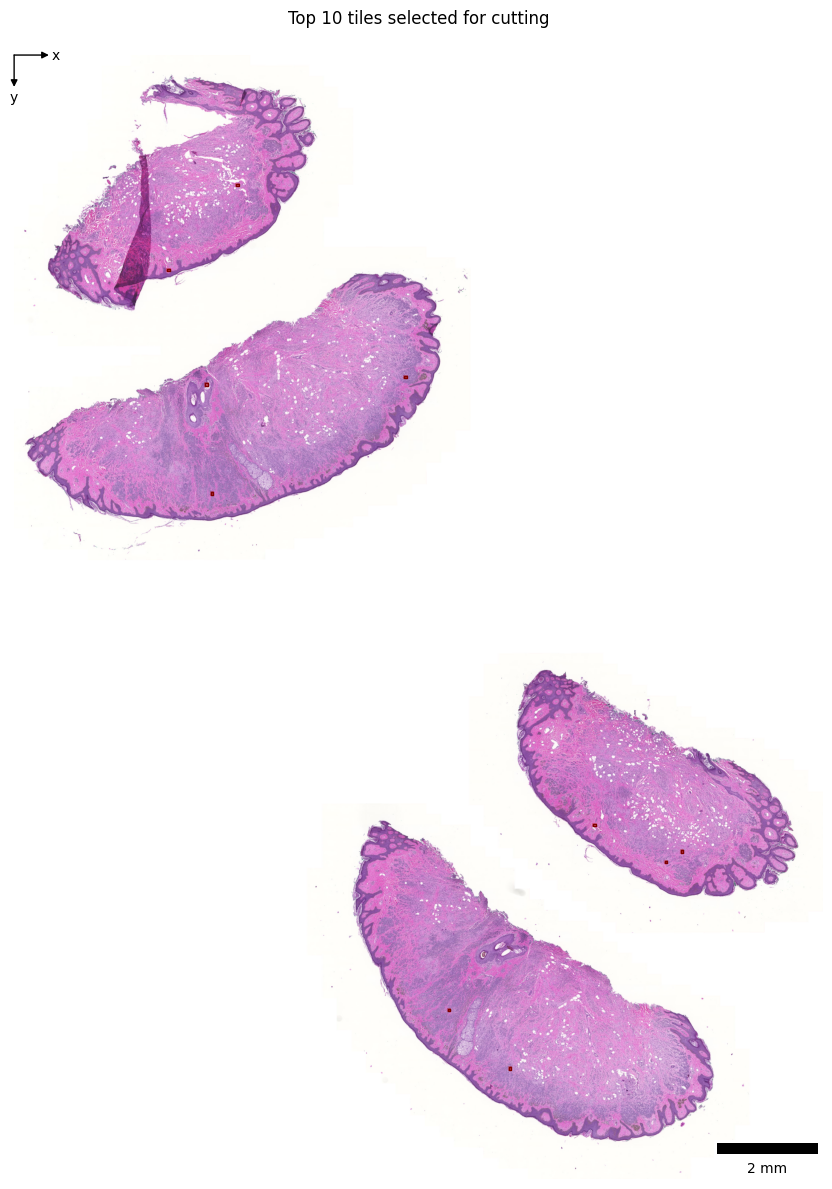

In [13]:
from roi_selection import ROISelector

selector = ROISelector(cache_path = inference_path, slide_path = path_CMU1, top_k = 10)
selector.tiles_to_cut()